# Multimodal Fine Tuned Representations on LLaVA: Layerwise vs Headwise Analysis

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from scripts.analyze_heads_representations import plot_overlap_heatmap

## Functions

In [2]:
def compute_layers_stats_across_heads(df):
    return df.apply(
        lambda row: pd.Series(
            {
                "mean": row.mean(),
                "std": row.std(),
                "min": row.min(),
                "max": row.max(),
                "median": row.median(),
            }
        ),
        axis=1,
    )


def plot_overlap(
    data_dict,
    plot_params_dict=None,
    figsize=(12, 6),
    title="Overlap Text vs Multimodal",
):
    """
    Parameters:
    - data_dict: dictionary with dataset names as keys and DataFrames as values
    - 
    - figsize: tuple, size of the figure
    - title: plot title
    """

    plt.figure(figsize=figsize)
    for dataset_name, df in data_dict.items():
        color = plot_params_dict[dataset_name]["color"]
        linestyle = plot_params_dict[dataset_name]["linestyle"]
        marker = "o"
        if linestyle != "solid":
            marker = "x"
        plt.plot(
            df.index.astype(int),
            df["data"].to_numpy(),
            label=dataset_name,
            marker=marker,
            color=color,
            linestyle=linestyle,
        )

    plt.xlabel("Layer Index")
    plt.ylabel("Neighborhood Overlap")
    plt.ylim(0, 1)
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


## Analysis

In [3]:
heads_rep_mmlu_path = "../results/neighborhood_overlaps/heads_representations/layer-head-overlap_llava-hf_llava-1.5-7b-hf_vs_lmsys_vicuna-7b-v1.5_mmlu_test_heads_representations_layer-all_token-last_texts-qa_chat-format_qinst-type-singular_guide-text_continue-fm_downsample-2500_seed-42_batch-1_maxk-30.parquet"
heads_rep_scienceqa_text_path = "../results/neighborhood_overlaps/heads_representations/layer-head-overlap_llava-hf_llava-1.5-7b-hf_vs_lmsys_vicuna-7b-v1.5_ScienceQA_test_heads_representations_layer-all_token-last_texts-qa_chat-format_qinst-type-singular_guide-text_continue-fm_seed-42_batch-1_maxk-30.parquet"
heads_rep_scienceqa_images_path = "../results/neighborhood_overlaps/heads_representations/layer-head-overlap_llava-hf_llava-1.5-7b-hf_vs_lmsys_vicuna-7b-v1.5_ScienceQA_test_heads_representations_layer-all_token-last_images-qa_chat-format_qinst-type-singular_guide-text_continue-fm_seed-42_batch-1_maxk-30.parquet"
heads_rep_cocoqa_text_path = "../results/neighborhood_overlaps/heads_representations/layer-head-overlap_llava-hf_llava-1.5-7b-hf_vs_lmsys_vicuna-7b-v1.5_cocoqa_captioning_restval_heads_representations_layer-all_token-last_texts-qa_chat-format_continue-fm_downsample-2500_seed-42_batch-1_maxk-30.parquet"
heads_rep_cocoqa_image_path = "../results/neighborhood_overlaps/heads_representations/layer-head-overlap_llava-hf_llava-1.5-7b-hf_vs_lmsys_vicuna-7b-v1.5_cocoqa_captioning_restval_heads_representations_layer-all_token-last_images-qa_chat-format_continue-fm_downsample-2500_seed-42_batch-1_maxk-30.parquet"

layers_rep_mmlu_path = "../results/neighborhood_overlaps/layers_representations/layer-overlap_llava-hf_llava-1.5-7b-hf_vs_lmsys_vicuna-7b-v1.5_mmlu_test_layers_representations_layer-all_token-last_texts-qa_chat-format_qinst-type-singular_continue-fm_downsample-2500_seed-42_maxk-30.csv"
layers_rep_scienceqa_text_path = "../results/neighborhood_overlaps/layers_representations/layer-overlap_llava-hf_llava-1.5-7b-hf_vs_lmsys_vicuna-7b-v1.5_ScienceQA_test_layers_representations_layer-all_token-last_texts-qa_chat-format_qinst-type-singular_continue-fm_seed-42_maxk-30.csv"
layers_rep_scienceqa_images_path = "../results/neighborhood_overlaps/layers_representations/layer-overlap_llava-hf_llava-1.5-7b-hf_vs_lmsys_vicuna-7b-v1.5_ScienceQA_test_layers_representations_layer-all_token-last_images-qa_chat-format_qinst-type-singular_continue-fm_seed-42_maxk-30.csv"
layers_rep_cocoqa_text_path = "../results/neighborhood_overlaps/layers_representations/layer-overlap_llava-hf_llava-1.5-7b-hf_vs_lmsys_vicuna-7b-v1.5_cocoqa_captioning_restval_layers_representations_layer-all_token-last_texts-qa_chat-format_continue-fm_downsample-2500_seed-42_maxk-30.csv"
layers_rep_cocoqa_images_path = "../results/neighborhood_overlaps/layers_representations/layer-overlap_llava-hf_llava-1.5-7b-hf_vs_lmsys_vicuna-7b-v1.5_cocoqa_captioning_restval_layers_representations_layer-all_token-last_images-qa_chat-format_continue-fm_downsample-2500_seed-42_maxk-30.csv"

In [4]:
heads_rep_mmlu_df = pd.read_parquet(heads_rep_mmlu_path)
heads_rep_scienceqa_text_df = pd.read_parquet(heads_rep_scienceqa_text_path)
heads_rep_scienceqa_images_df = pd.read_parquet(heads_rep_scienceqa_images_path)
heads_rep_cocoqa_text_df = pd.read_parquet(heads_rep_cocoqa_text_path)
heads_rep_cocoqa_image_df = pd.read_parquet(heads_rep_cocoqa_image_path)

layers_rep_mmlu_df = pd.read_csv(layers_rep_mmlu_path, index_col=0)
layers_rep_scienceqa_text_df = pd.read_csv(layers_rep_scienceqa_text_path, index_col=0)
layers_rep_scienceqa_images_df = pd.read_csv(
    layers_rep_scienceqa_images_path, index_col=0
)
layers_rep_cocoqa_text_df = pd.read_csv(layers_rep_cocoqa_text_path, index_col=0)
layers_rep_cocoqa_image_df = pd.read_csv(layers_rep_cocoqa_images_path, index_col=0)

heads_rep_scienceqa_text_minus_images_df = (
    heads_rep_scienceqa_text_df - heads_rep_scienceqa_images_df
)
heads_rep_cocoqa_text_minus_images_df = (
    heads_rep_cocoqa_text_df - heads_rep_cocoqa_image_df
)

mmlu_layers_stats_across_heads = compute_layers_stats_across_heads(heads_rep_mmlu_df)
scienceqa_text_layers_stats_across_heads = compute_layers_stats_across_heads(
    heads_rep_scienceqa_text_df
)
scienceqa_images_layers_stats_across_heads = compute_layers_stats_across_heads(
    heads_rep_scienceqa_images_df
)
cocoqa_text_layers_stats_across_heads = compute_layers_stats_across_heads(
    heads_rep_cocoqa_text_df
)
cocoqa_image_layers_stats_across_heads = compute_layers_stats_across_heads(
    heads_rep_cocoqa_image_df
)

layerwise_overlap_data_dict = {
"MMLU LW": layers_rep_mmlu_df.rename(
        columns={"Neighborhood Overlap": "data"}
    ),
    "SQA TXT LW": layers_rep_scienceqa_text_df.rename(
        columns={"Neighborhood Overlap": "data"}
    ),
    "SQA IMG LW": layers_rep_scienceqa_images_df.rename(
        columns={"Neighborhood Overlap": "data"}
    ),
    "COCOQA TXT LW": layers_rep_cocoqa_text_df.rename(
        columns={"Neighborhood Overlap": "data"}
    ),
    "COCOQA IMG LW": layers_rep_cocoqa_image_df.rename(
        columns={"Neighborhood Overlap": "data"}
    ),
}
layerwise_overlap_plot_params_dict = {
    "MMLU LW": {"color": "orange", "linestyle": "dashdot"},
    "SQA TXT LW": {"color": "blue", "linestyle": "dashdot"},
    "SQA IMG LW": {"color": "gray", "linestyle": "dashdot"},
    "COCOQA TXT LW": {"color": "olive", "linestyle": "dashdot"},
    "COCOQA IMG LW": {"color": "purple", "linestyle": "dashdot"},
}

heads_overlap_data_dict = {
    "MMLU MH": mmlu_layers_stats_across_heads[["mean"]].rename(
        columns={"mean": "data"}
    ),
    "SQA TXT MH": scienceqa_text_layers_stats_across_heads[
        ["mean"]
    ].rename(columns={"mean": "data"}),
    "SQA IMG MH": scienceqa_images_layers_stats_across_heads[
        ["mean"]
    ].rename(columns={"mean": "data"}),
    "COCOQA TXT MH": cocoqa_text_layers_stats_across_heads[["mean"]].rename(
        columns={"mean": "data"}
    ),
    "COCOQA IMG MH": cocoqa_image_layers_stats_across_heads[["mean"]].rename(
        columns={"mean": "data"}
    ),
    
}
heads_overlap_plot_params_dict = {
    "MMLU MH": {"color": "orange", "linestyle": "solid"},
    "SQA TXT MH": {"color": "blue", "linestyle": "solid"},
    "SQA IMG MH": {"color": "gray", "linestyle": "solid"},
    "COCOQA TXT MH": {"color": "olive", "linestyle": "solid"},
    "COCOQA IMG MH": {"color": "purple", "linestyle": "solid"},
    
}

Max overall overlap value: 0.40
Min overall overlap value: -0.20


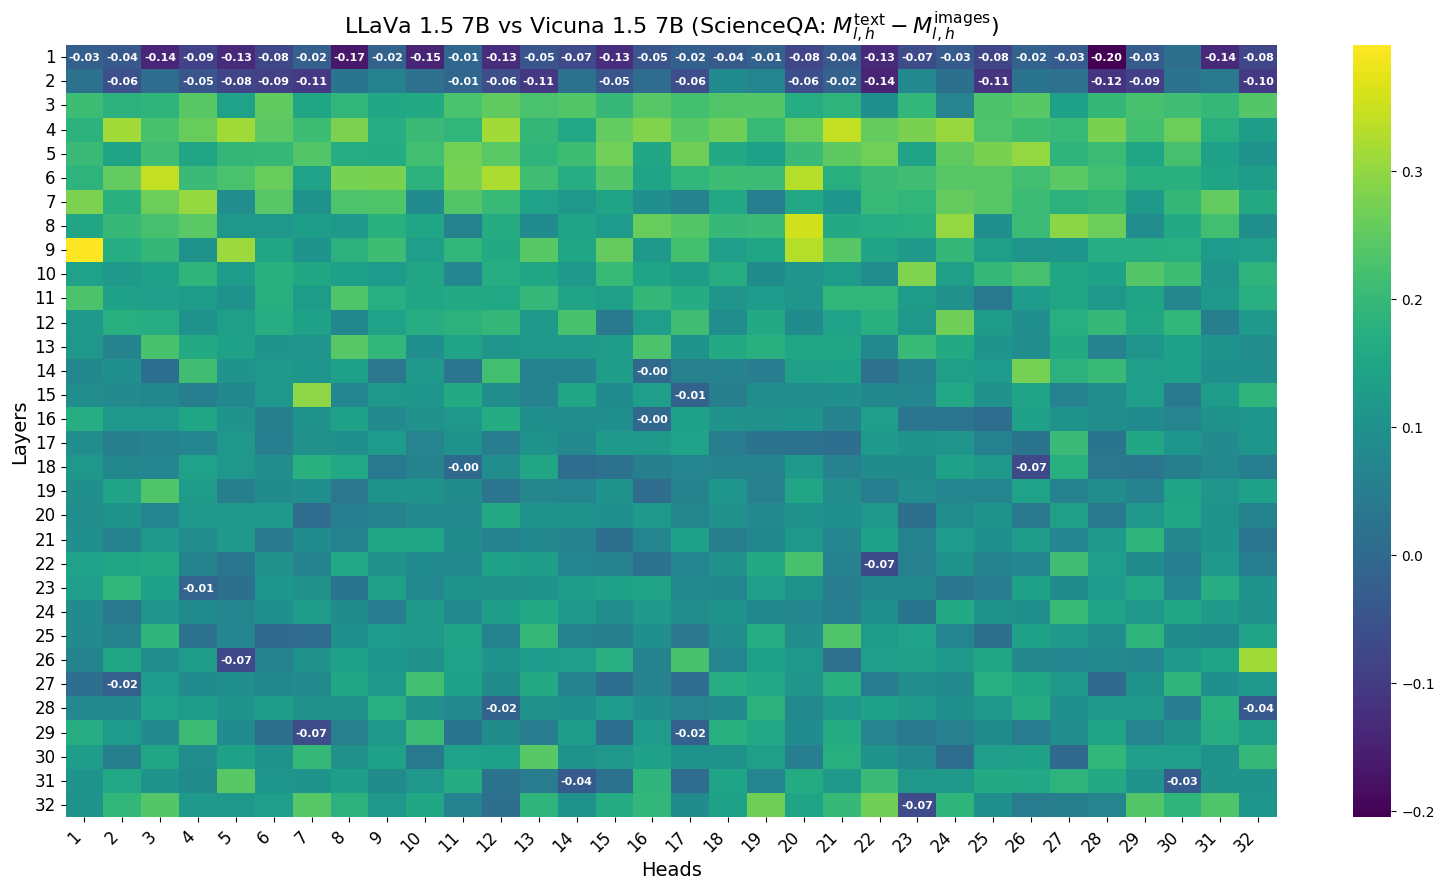

In [5]:
plot_overlap_heatmap(
    heads_rep_scienceqa_text_minus_images_df,
    title=r"LLaVa 1.5 7B vs Vicuna 1.5 7B (ScienceQA: $M^{\mathrm{text}}_{l,h} - M^{\mathrm{images}}_{l,h}$)",
    figsize=(16, 9),
)


Max overall overlap value: 0.46
Min overall overlap value: -0.25


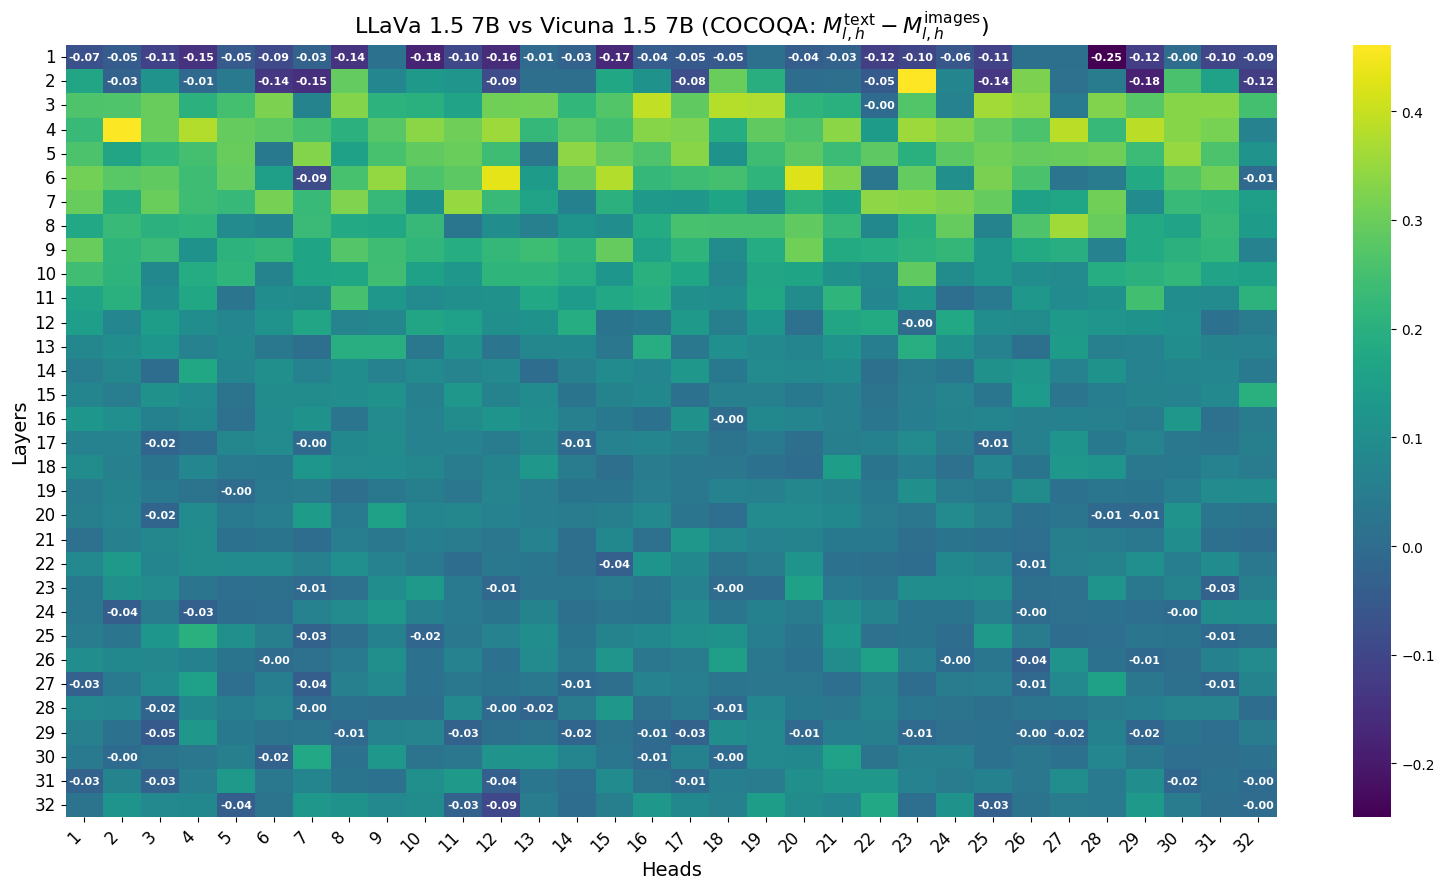

In [6]:
plot_overlap_heatmap(
    heads_rep_cocoqa_text_minus_images_df,
    title=r"LLaVa 1.5 7B vs Vicuna 1.5 7B (COCOQA: $M^{\mathrm{text}}_{l,h} - M^{\mathrm{images}}_{l,h}$)",
    figsize=(16, 9),
)


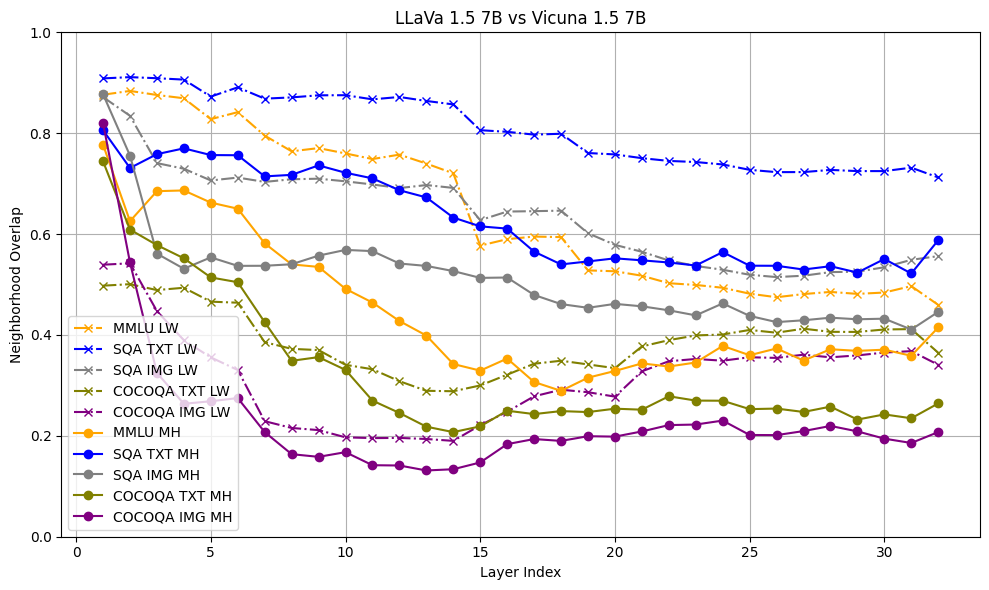

In [7]:
plot_overlap(
    data_dict={
        **layerwise_overlap_data_dict,
        **heads_overlap_data_dict,
    },
    plot_params_dict={
        **layerwise_overlap_plot_params_dict,
        **heads_overlap_plot_params_dict,
    },
    figsize=(10, 6),
    title="LLaVa 1.5 7B vs Vicuna 1.5 7B",
)

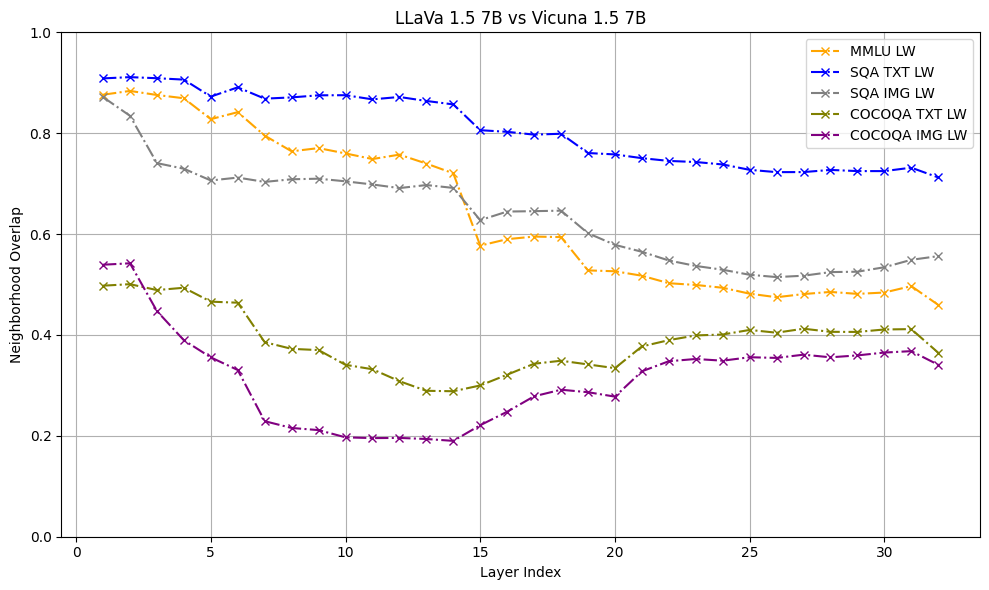

In [8]:
plot_overlap(
    data_dict={
        **layerwise_overlap_data_dict,
    },
    plot_params_dict={
        **layerwise_overlap_plot_params_dict,
    },
    figsize=(10, 6),
    title="LLaVa 1.5 7B vs Vicuna 1.5 7B",
)

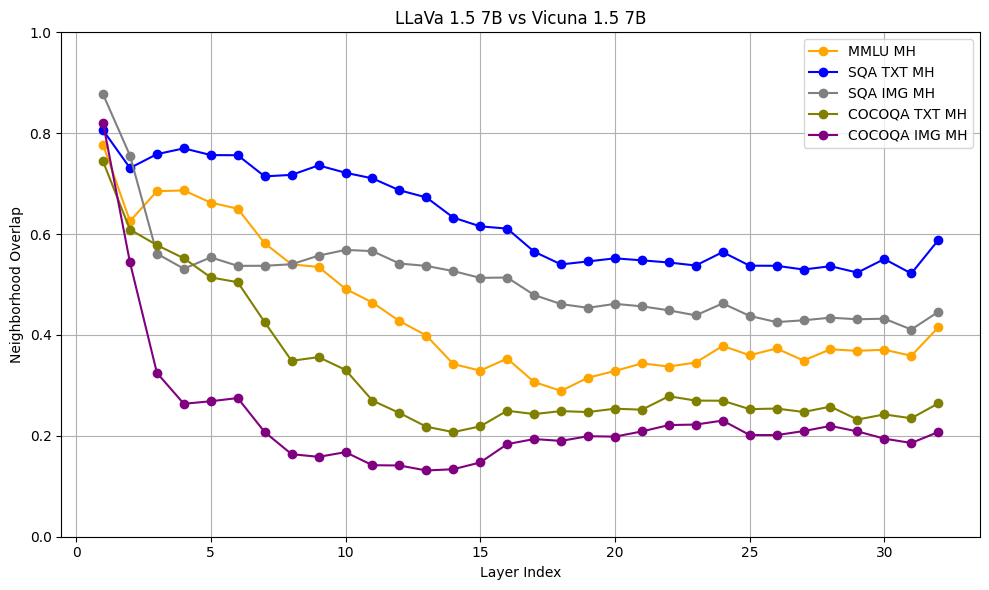

In [9]:
plot_overlap(
    data_dict={
        **heads_overlap_data_dict,
    },
    plot_params_dict={
        **heads_overlap_plot_params_dict,
    },
    figsize=(10, 6),
    title="LLaVa 1.5 7B vs Vicuna 1.5 7B",
)

## Removed Code

In [ ]:
import numpy as np
from ipywidgets import interact, FloatSlider, Dropdown
from IPython.display import clear_output


def binary_op(A_bin, B_bin, operation):
    if operation == "xor":
        return np.logical_xor(A_bin, B_bin).astype(int)
    elif operation == "or":
        return np.logical_or(A_bin, B_bin).astype(int)
    elif operation == "and":
        return np.logical_and(A_bin, B_bin).astype(int)
    else:
        raise ValueError(f"Unknown operation '{operation}'")


def visualize_matrix(A, B, threshold, operation):
    clear_output(wait=True)  # This clears previous output in the cell
    A_bin = A > threshold
    B_bin = B > threshold
    result = binary_op(A_bin, B_bin, operation)

    plt.figure(figsize=(5, 5))
    plt.imshow(result, cmap="gray", vmin=0, vmax=1)
    plt.title(
        rf"${{{operation.upper()}}}: M^{{\text{{text}}}}_{{\geq \tau}} \oplus M^{{\text{{images}}}}_{{\geq \tau}},\ \tau = {threshold:.2f}$"
    )
    plt.axis("off")
    plt.show()


# Dropdown for operation and slider for threshold
def binary_heads_change(A, B):
    interact(
        lambda t, op: visualize_matrix(A, B, t, op),
        t=FloatSlider(min=0, max=1, step=0.01, value=0.5, description="Threshold"),
        op=Dropdown(options=["xor", "or", "and"], value="xor", description="Operation"),
    )


def visualize_matrix_subplot(ax, A, B, threshold, operation):
    A_bin = A >= threshold
    B_bin = B <= threshold
    result = binary_op(A_bin, B_bin, operation)

    ax.imshow(result, cmap="gray", vmin=0, vmax=1)
    ax.set_title(rf"$\tau = {threshold:.2f}$", fontsize=10)
    ax.axis("off")


# Main plotting code
def plot_all_thresholds(A, B, thresholds, operation, rows=4, cols=3):
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))
    axes = axes.flatten()  # Flatten in case it's 2D

    for i, threshold in enumerate(thresholds):
        if i < len(axes):
            visualize_matrix_subplot(axes[i], A, B, threshold, operation)

    # Hide any unused axes (if thresholds < rows * cols)
    for j in range(len(thresholds), len(axes)):
        axes[j].axis("off")

    fig.suptitle(
        rf"${operation.upper()}: M^{{\text{{text}}}}_{{\geq \tau}} \oplus M^{{\text{{images}}}}_{{\geq \tau}}$",
        fontsize=16,
    )

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # Leave space for suptitle
    plt.show()


def plot_box_plot_layerwise_stats_across_heads(
    df,
    dataset_name="Dataset",
):
    """
    Plots a box plot of layerwise statistics across heads.
    Parameters:
    - df: pandas DataFrame with index like L0, L1, ..., L31 and columns like 'mean', 'std', 'min', etc.
    """

    # Transpose the DataFrame so that rows become columns for plotting
    plt.boxplot(df.T, vert=False)
    plt.yticks(
        ticks=range(1, len(df) + 1),
        labels=df.index,
    )
    plt.xlim(0, 1)
    plt.xlabel("Neighborhood Overlap (LLaVa 1.5 7b vs Vicuna 1.5 7B)")
    plt.ylabel("Layer Index")
    plt.title(f"Layerwise Statistics of Heads Representations ({dataset_name})")
    plt.show()


def plot_overlap_heads_moments_vs_layerwise(
    overlap_heads_moments_df,
    layerwise_overlap_df,
    figsize=(12, 6),
    dataset_name="Dataset",
):
    """
    Plots selected row-wise statistics against layer index.

    Parameters:
    - overlap_heads_moments_df: pandas DataFrame with index like L0, L1, ..., L31 and columns like 'mean', 'std', 'min', etc.
    - layerwise_overlap_df: pandas DataFrame with layerwise overlap statistics
    - figsize: tuple, size of the figure
    - title: plot title
    """

    x = overlap_heads_moments_df.index.to_numpy()
    mean = overlap_heads_moments_df["mean"].to_numpy()
    std = overlap_heads_moments_df["std"].to_numpy()
    upper = mean + std
    lower = mean - std

    stats_to_plot = overlap_heads_moments_df.columns.difference(["mean", "std"])

    # Plot
    plt.figure(figsize=figsize)
    for stat in stats_to_plot:
        plt.plot(overlap_heads_moments_df[stat], marker="o", label=stat)

    # Plot mean and std as band
    plt.plot(x, mean, marker="o", label="Mean", linewidth=2)
    plt.fill_between(x, lower, upper, alpha=0.2, label="±1 Std Dev")

    # Plot layerwise overlap
    plt.plot(
        layerwise_overlap_df.index,
        layerwise_overlap_df["Neighborhood Overlap"],
        marker="o",
        label="Layerwise",
        color="orange",
    )

    plt.xlabel("Layer Index")
    plt.ylabel("Neighborhood Overlap")
    plt.ylim(0, 1)
    plt.title(f"Heads Moments vs Layerwise Overlap ({dataset_name})")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


def plot_layerwise_stats_across_heads(
    df,
    figsize=(12, 6),
    dataset_name="Dataset",
):
    """
    Plots selected row-wise statistics against layer index.

    Parameters:
    - df: pandas DataFrame with index like L0, L1, ..., L31 and columns like 'mean', 'std', 'min', etc.
    - figsize: tuple, size of the figure
    - title: plot title
    """

    x = df.index.to_numpy()
    mean = df["mean"].to_numpy()
    std = df["std"].to_numpy()
    upper = mean + std
    lower = mean - std

    stats_to_plot = df.columns.difference(["mean", "std"])

    # Plot
    plt.figure(figsize=figsize)
    for stat in stats_to_plot:
        plt.plot(df[stat], marker="o", label=stat)

    # Plot mean and std as band
    plt.plot(x, mean, marker="o", color="purple", label="Mean", linewidth=2)
    plt.fill_between(x, lower, upper, color="blue", alpha=0.2, label="±1 Std Dev")

    plt.xlabel("Layer Index")
    plt.ylabel("Neighborhood Overlap Moments Value")
    plt.ylim(0, 1)
    plt.title(dataset_name)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


def plot_overlap_layerwise_vs_heads_mean(
    layerwise_overlap_df,
    heads_mean_overlap_np,
    dataset_name="Dataset",
    figsize=(12, 6),
):
    x = layerwise_overlap_df.index.to_numpy()

    plt.figure(figsize=figsize)
    plt.plot(
        x,
        layerwise_overlap_df["Neighborhood Overlap"],
        marker="o",
        label="Layerwise",
    )
    plt.plot(
        x,
        heads_mean_overlap_np,
        marker="o",
        label="Heads Mean",
    )
    plt.xlabel("Layer Index")
    plt.ylabel("Neighborhood Overlap")
    plt.ylim(0, 1)
    plt.title(dataset_name)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [ ]:
# upper_limit = 85
# lower_limit = 30
# step = 5
# values = (
#     np.arange(lower_limit, upper_limit + 1, step) / 100.0
# )  # Convert to [0, 1] range

# binary_heads_change(
#     heads_rep_scienceqa_text_np,
#     heads_rep_scienceqa_images_np,
# )

# binary_heads_change(
#     znormalized_heads_rep_scienceqa_text_np,
#     znormalized_heads_rep_scienceqa_images_np,
# )

# plot_all_thresholds(
#     heads_rep_scienceqa_text_np,
#     heads_rep_scienceqa_images_np,
#     thresholds,
#     "and",
#     rows=4,
#     cols=3,
# )
# plot_all_thresholds(
#     znormalized_heads_rep_scienceqa_text_np,
#     znormalized_heads_rep_scienceqa_images_np,
#     thresholds,
#     "xor",
#     rows=4,
#     cols=3,
# )

# plot_overlap_heatmap(
#     znormalized_heads_rep_scienceqa_text_minus_images_df,
#     title=r"LLaVa 1.5 7B vs Vicuna 1.5 7B (ScienceQA: $Z^{\mathrm{text}}_{l,h} - Z^{\mathrm{images}}_{l,h}$)",
# )


In [ ]:
# plot_box_plot_layerwise_stats_across_heads(
#     heads_rep_mmlu_df,
#     dataset_name="MMLU",
# )
# plot_box_plot_layerwise_stats_across_heads(
#     heads_rep_scienceqa_text_df,
#     dataset_name="ScienceQA Text",
# )
# plot_box_plot_layerwise_stats_across_heads(
#     heads_rep_scienceqa_images_df,
#     dataset_name="ScienceQA Images",
# )

# plot_overlap_heads_moments_vs_layerwise(
#     mmlu_layers_stats_across_heads,
#     layers_rep_mmlu_df,
#     dataset_name="MMLU",
#     figsize=(10, 6),
# )
# plot_overlap_heads_moments_vs_layerwise(
#     scienceqa_text_layers_stats_across_heads,
#     layers_rep_scienceqa_text_df,
#     dataset_name="ScienceQA Text",
#     figsize=(10, 6),
# )
# plot_overlap_heads_moments_vs_layerwise(
#     scienceqa_images_layers_stats_across_heads,
#     layers_rep_scienceqa_images_df,
#     dataset_name="ScienceQA Images",
#     figsize=(10, 6),
# )

In [ ]:
# plot_layerwise_stats_across_heads(
#     mmlu_layers_stats_across_heads,
#     dataset_name="MMLU",
#     figsize=(10, 6),
# )
# plot_layerwise_stats_across_heads(
#     scienceqa_text_layers_stats_across_heads,
#     dataset_name="ScienceQA Text",
#     figsize=(10, 6),
# )
# plot_layerwise_stats_across_heads(
#     scienceqa_images_layers_stats_across_heads,
#     dataset_name="ScienceQA Images",
#     figsize=(10, 6),
# )

# plot_overlap_layerwise_vs_heads_mean(
#     layers_rep_mmlu_df,
#     mmlu_layers_stats_across_heads["mean"].to_numpy(),
#     dataset_name="MMLU",
# )
# plot_overlap_layerwise_vs_heads_mean(
#     layers_rep_scienceqa_text_df,
#     scienceqa_text_layers_stats_across_heads["mean"].to_numpy(),
#     dataset_name="ScienceQA Text",
# )
# plot_overlap_layerwise_vs_heads_mean(
#     layers_rep_scienceqa_images_df,
#     scienceqa_images_layers_stats_across_heads["mean"].to_numpy(),
#     dataset_name="ScienceQA Images",
# )